# DS 5003, SP 2026 - Healthcare Data Science 

## *For Professor Christian Wernz, PhD, University of Virginia*

---

#### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science*  gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science*  kxp3jj@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science*  amp3xs@virginia.edu
* **Jasmine Waller** | *University of Virginia, School of Data Science*  vwx5pn@virginia.edu

# CMS HAI Risk Prediction Pipeline
**Objective:** Develop a tool to determine if a facility is at risk of an HAI incident (HAI_1 through HAI_6) and identify which facility measures contribute most to correcting an "at-risk" status.

In [25]:
import sys
import numpy as np
import importlib
from pathlib import Path
import matplotlib.pyplot as plt

RANDOM_SEED = 42
# Set for numpy, pandas, and sklearn
np.random.seed(RANDOM_SEED)

# Add the 'code' folder to the system path so Python can find your scripts
if './code' not in sys.path:
    sys.path.append('./code')

print("Pipeline initialized. Ready to execute modules.")

Pipeline initialized. Ready to execute modules.


## 00: Data Retrieval

This step performs a self-healing raw-data check for the CMS hospital downloadable database.

The goal is to make the pipeline reproducible and portable. Rather than assuming the data already exists locally, the script checks whether a known CMS hospital CSV is present in the target raw-data folder. If the data is already available, the step is skipped. If not, the script downloads the current CMS hospital archive directly from the CMS Provider Data Catalog archive, extracts the contents into the project raw-data directory, and removes the zip file after extraction.

This design keeps the pipeline easier to run on a new machine and reduces manual setup errors.

In [26]:
step_00 = importlib.import_module("00_download_data")
importlib.reload(step_00)

download_success, raw_data_path = step_00.download_and_extract_cms_data()

print(f"Download success: {download_success}")
print(f"Resolved raw data path: {raw_data_path}")

[SKIP] CMS data already exists at: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
Download success: True
Resolved raw data path: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026


## 01: Data Import

This step dynamically scans the CMS raw-data directory and imports every CSV file found in the extracted hospital archive.

The design choice here is to avoid hard-coding a small list of expected files. Instead, the script loads all available hospital-level, state-level, and national-level files into a dictionary of pandas DataFrames. This makes the pipeline more adaptable to future CMS archive updates, where files may be added, removed, or renamed between releases.

Column names are lightly standardized by stripping leading and trailing whitespace, but the original CMS naming conventions are otherwise preserved so that downstream steps remain interpretable against the CMS data dictionary.

In [27]:
# Import the module dynamically
step_01 = importlib.import_module("01_data_import")
importlib.reload(step_01)

# Execute the raw-data loading function
raw_datasets = step_01.load_all_raw_data()

print(f"\nTotal datasets loaded: {len(raw_datasets)}")

Scanning directory: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
--------------------------------------------------
Found 73 CSV files. Beginning import...

[LOADED] ASC_Facility                             | Rows: 5711    | Cols: 47
[LOADED] ASC_National                             | Rows: 1       | Cols: 37
[LOADED] ASC_State                                | Rows: 54      | Cols: 34
[LOADED] ASCQR_OAS_CAHPS_BY_ASC                   | Rows: 4452    | Cols: 30
[LOADED] ASCQR_OAS_CAHPS_NATIONAL                 | Rows: 1       | Cols: 21
[LOADED] ASCQR_OAS_CAHPS_STATE                    | Rows: 56      | Cols: 22
[LOADED] Birthing_Friendly_Hospitals_Geocoded     | Rows: 2265    | Cols: 7
[LOADED] CJR_Quality_Reporting_January_2026_Produ | Rows: 320     | Cols: 18
[LOADED] CMS_PSI_6_decimal_file                   | Rows: 52327   | Cols: 13
[LOADED] Complications_and_Deaths-Hospital        | Rows: 95780   | Cols: 18
[LOADED] Com

## 02: Data Interpretation

This step profiles all imported CMS datasets and creates a structured inventory report to support downstream dataset screening.

The purpose of this step is not modeling yet. Instead, it functions as a quality and usability audit of the available CMS files. For each dataset, the profile summarizes its size, memory footprint, the presence of facility identifiers, whether a `Measure ID` field exists, whether a likely value column exists, and whether the file appears suitable for hospital-level feature mining.

This gives the team a more systematic basis for deciding which datasets are likely to contribute useful predictors and which ones are primarily state-level, national-level, administrative, or otherwise low-value for the modeling objective.

In [28]:
step_02 = importlib.import_module("02_data_interpretation")
importlib.reload(step_02)

# Generate the dataset profile report
if raw_datasets:
    data_profile = step_02.generate_data_profile(raw_datasets)
    display(data_profile.head(15))
else:
    print("No data available to profile.")


Analyzing datasets...

[SUCCESS] Data interpretation profile saved to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\interim\dataset_inventory_profile.csv
[INFO] Review this CSV to identify facility-level hospital files,
       likely feature sources, and low-value summary datasets.


,Dataset_Name,Row_Count,Column_Count,Has_Facility_ID,Facility_ID_Column,Unique_Facility_IDs,Has_Measure_ID,Measure_ID_Column,Likely_Value_Column,Potential_Hospital_File,Memory_MB,Columns_List
0,Healthcare_Associated_Infections-Hospital,172404,15,True,Facility ID,4789.0,True,Measure ID,Score,True,145.91,"Facility ID, Facility Name, Address, City/Town..."
1,Timely_and_Effective_Care-Hospital,138129,16,True,Facility ID,4657.0,True,Measure ID,Score,True,126.30,"Facility ID, Facility Name, Address, City/Town..."
2,Complications_and_Deaths-Hospital,95780,18,True,Facility ID,4789.0,True,Measure ID,Score,True,95.69,"Facility ID, Facility Name, Address, City/Town..."
3,Unplanned_Hospital_Visits-Hospital,67046,20,True,Facility ID,4789.0,True,Measure ID,Score,True,75.94,"Facility ID, Facility Name, Address, City/Town..."
4,Outpatient_Imaging_Efficiency-Hospital,18500,14,True,Facility ID,4625.0,True,Measure ID,Score,True,13.33,"Facility ID, Facility Name, Address, City/Town..."
5,Maternal_Health-Hospital,17968,15,True,Facility ID,4657.0,True,Measure ID,Score,True,14.40,"Facility ID, Facility Name, Address, City/Town..."
6,Medicare_Hospital_Spending_Per_Patient-Hospital,4625,14,True,Facility ID,4625.0,True,Measure ID,Score,True,3.31,"Facility ID, Facility Name, Address, City/Town..."
7,PATIENT_REPORTED_OUTCOMES_FACILITY,4625,15,True,Facility ID,4625.0,True,Measure ID,Score,True,3.76,"Facility ID, Facility Name, Address, City/Town..."
8,HOSPITAL_QUARTERLY_MSPB_6_DECIMALS,2974,6,True,Facility ID,2974.0,True,Measure ID,Value,True,0.56,"Facility ID, Measure ID, Value, Footnote, Star..."
9,VA_TE,1452,17,True,Facility ID,132.0,True,Measure ID,Score,True,1.37,"Facility ID, Facility Name, Address, City/Town..."


## 03: Data-Driven Ground Truth Construction

The predictive target is based on the CMS Standardized Infection Ratio (SIR), which is a risk-adjusted measure comparing a facility’s observed infection burden to a benchmarked expected value. In the CMS hospital HAI files, a value greater than 1.0 indicates worse-than-benchmark performance on that infection measure.

The primary binary outcome for this project is `HAI_at_risk`. A facility is assigned `HAI_at_risk = 1` if any reported HAI SIR measure exceeds 1.0. This treats elevated HAI risk as a facility-level vulnerability rather than as a single isolated infection event.

To preserve the interpretability of the target construction step, the pipeline now saves two outputs:

1. A detailed facility-level HAI target file containing counts of reported HAI SIR measures, counts of worse-than-benchmark measures, and facility-level HAI subtype indicators.
2. A master modeling file containing the primary binary target merged with a small set of structural hospital descriptors from the CMS general hospital information file.

This preserves the original modeling target while creating richer target metadata for later interpretation and reporting.

In [29]:
step_03 = importlib.import_module("03_data_processing")
importlib.reload(step_03)

if "raw_datasets" in locals():
    master_data = step_03.build_target_and_master(raw_datasets)
    display(master_data.head())
else:
    print("raw_datasets not found. Run Step 01 first.")

--- 03 Processing Complete ---
Total Facilities in target detail file: 4789
Total Facilities in master modeling file: 4789
At Risk Count: 1432
[SUCCESS] Saved target detail file to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\facility_hai_target_detail.csv
[SUCCESS] Saved master modeling file to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\master_model_data.csv


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3
2,010006,0,Acute Care Hospitals,Proprietary,2
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1
4,010008,0,Acute Care Hospitals,Proprietary,Not Available


## 04: Exploratory Data Analysis

Before moving into feature mining and model fitting, this step summarizes the facility population represented in the master modeling file.

The goal of this stage is to provide a compact descriptive view of the dataset rather than an exhaustive exploratory analysis. In particular, the step examines:

1. the overall distribution of the binary HAI risk target,
2. differences in at-risk rates across hospital types,
3. differences in at-risk rates across hospital ownership categories, and
4. missingness patterns in the small set of structural variables retained from the CMS general hospital information file.

These outputs serve two purposes. First, they help verify that the target construction step produced a plausible population for modeling. Second, they provide context for interpreting later model results, especially when structural or organizational features appear to be associated with HAI risk.

[SUCCESS] Saved class distribution table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_class_distribution.csv


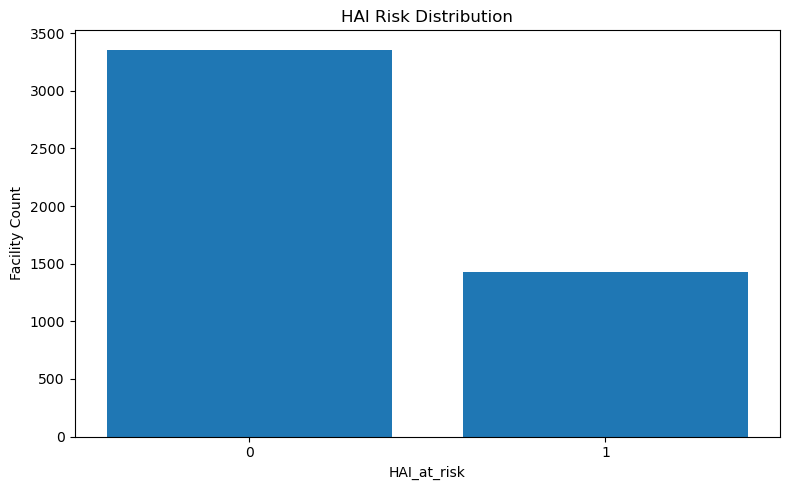

[SUCCESS] Saved figure to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\eda_hai_risk_distribution.png
[SUCCESS] Saved hospital type summary table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_hospital_type_summary.csv


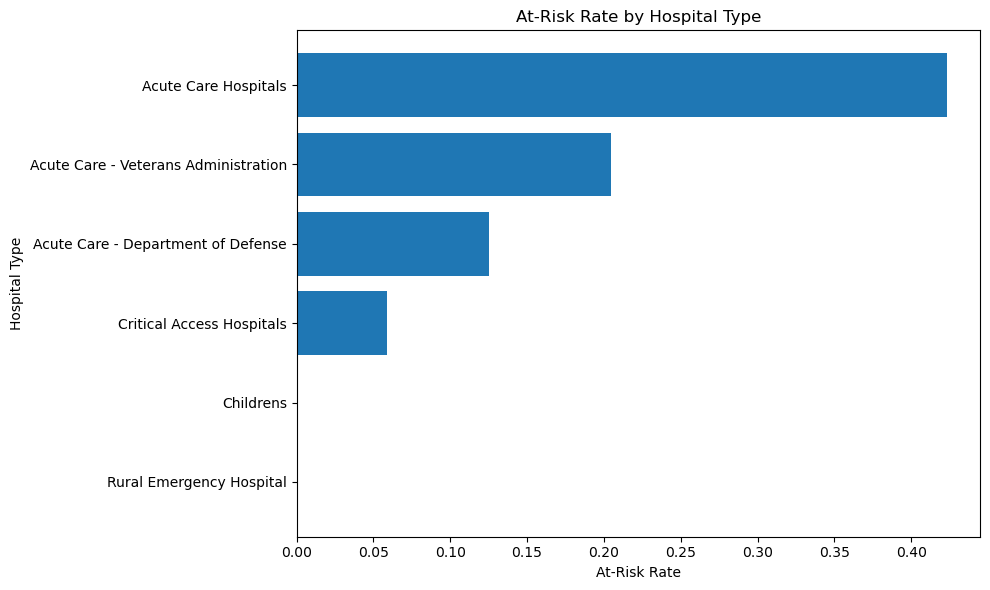

[SUCCESS] Saved figure to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\eda_at_risk_rate_by_hospital_type.png
[SUCCESS] Saved hospital ownership summary table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_hospital_ownership_summary.csv


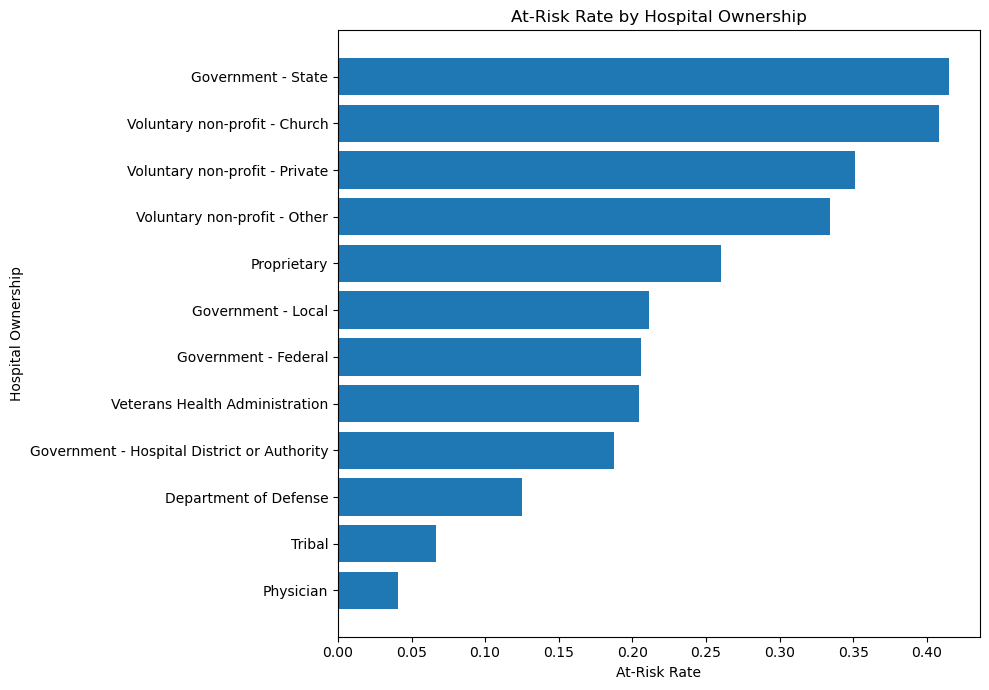

[SUCCESS] Saved figure to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\eda_at_risk_rate_by_hospital_ownership.png
[SUCCESS] Saved structural missingness summary table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_structural_missingness_summary.csv
[SUCCESS] Step 04 EDA complete.


In [30]:
step_04 = importlib.import_module("04_data_analysis")
importlib.reload(step_04)

if "master_data" in locals():
    eda_outputs = step_04.run_eda()
else:
    print("master_data not found. Run Step 03 first.")

# 05: Dynamic Feature Discovery and Selection

### 1. The Master Anchor
The process begins with the **Master Modeling Set** (4,789 facilities). By using this as the anchor, the script ensures that every potential predictor is linked to a facility with a known `HAI_at_risk` label.

### 2. Automated File Screening
Instead of manually selecting files, the logic scans all available datasets and applies a **Statistical Gatekeeper** to ensure high-quality inputs:
* **Identity Check:** A file must contain a `Facility ID` to be eligible for the join.
* **Population Overlap (50% Threshold):** Only files that contain data for at least 50% of the target facilities are processed. This automatically filters out noise from specialized datasets or state-level summaries that do not provide enough context for the whole population.

### 3. Structural Reshaping (Long-to-Wide)
CMS data is natively stored in a "Long" format where each measurement occupies a row. Machine learning requires "Wide" data where each row is a unique observation (hospital) and each column is a feature (predictor).
* **Numeric Identification:** The script locates the specific numeric measurement column (e.g., `Score`, `Value`, or `HCAHPS Linear Mean Score`).
* **Pivoting:** The `Measure ID` is transformed into a column header, and the numeric result becomes the cell value. 

### 4. Density-Based Feature Selection
To prevent the model from overfitting on sparse data or "learning from noise," a **Sparsity Filter** is applied to the individual columns:
* If a specific measure (e.g., `MORT_30_PN`) is missing for more than 50% of the hospitals in the modeling set, that feature is discarded.
* This ensures the resulting features are robust, high-density predictors that exist across the majority of the population.

### 5. Final Synthesis and Imputation
The disparate data points—ranging from clinical outcomes to patient satisfaction—are merged via a **Left Join**:
* **Integrity:** The 4,789 facilities are preserved as the primary population.
* **Model Readiness:** Remaining missing values are imputed using the **column median**. This provides a stable baseline for algorithms like XGBoost or Random Forest, ensuring that the "Predictive Drivers" are derived from the central tendency of the evidence.

In [ ]:
step_05 = importlib.import_module("05_feature_identification")

if 'raw_datasets' in locals():
    final_df = step_05.mine_features(
        raw_datasets,
        exclude_files=["Healthcare_Associated_Infections-Hospital"]
    )
    display(final_df.head())

## Data Split and Cross-Validation

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
 
# 1. Setup the Stratified 5-Fold with Shuffling
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# 2. Separate Features and Target
X = final_df.drop('HAI_at_risk', axis=1)
y = final_df['HAI_at_risk']
 
# 3. Execution Loop
fold_results = []
 
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Verification: Check if the ratio of 'at_risk' remains consistent
    train_ratio = y_train.mean()
    test_ratio = y_test.mean()
    
    print(f"--- Fold {fold + 1} ---")
    print(f"Train At-Risk Ratio: {train_ratio:.2%}, Test At-Risk Ratio: {test_ratio:.2%}")
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

## Modeling Setup

The next stage builds a consistent modeling workflow across Logistic Regression, Random Forest, and XGBoost. A held-out test split is created for final comparison, while stratified 5-fold cross-validation is retained inside the training data for hyperparameter tuning. Separate preprocessing pipelines are used for linear and tree-based models so that categorical variables, missing values, and feature scaling are handled appropriately.

In [ ]:
# Modeling imports
import importlib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# Train/test split for final held-out evaluation
X = final_df.drop(columns=['HAI_at_risk',
                           'Facility ID', 
                           'Hospital overall rating',
                           'Hospital Type',
                           'Hospital Ownership'
                           ]
                )
y = final_df['HAI_at_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Train at-risk rate: {y_train.mean():.2%}")
print(f"Test at-risk rate: {y_test.mean():.2%}")

# Inner CV used for model tuning on the training set only
cv_inner = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

# Identify column types
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Preprocessing for Logistic Regression
numeric_transformer_scaled = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_logreg = ColumnTransformer([
    ('num', numeric_transformer_scaled, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Preprocessing for Random Forest and XGBoost
numeric_transformer_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocess_tree = ColumnTransformer([
    ('num', numeric_transformer_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Class-balance settings
class_weight_balanced = 'balanced'
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

# 06: Logistic Regression

Logistic Regression provides the most interpretable baseline in the modeling suite. Because it is a linear model, the preprocessing pipeline includes both imputation and feature scaling. Hyperparameters are tuned with stratified 5-fold cross-validation on the training set, and final performance is reserved for the held-out test set.

In [ ]:
# Step 06: Logistic Regression
step_06 = importlib.import_module("06_model_logreg")
importlib.reload(step_06)

logreg_cv, logreg_pipe, logreg_params = step_06.run_logreg_model(
    preprocess=preprocess_logreg,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    penalty='elasticnet',
    class_weight=class_weight_balanced,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring='roc_auc',
    n_jobs=-1
)

logreg_best = logreg_cv.best_estimator_

print("Best Logistic Regression CV ROC-AUC:", round(logreg_cv.best_score_, 4))
print("Best Logistic Regression Params:")
print(logreg_cv.best_params_)

logreg_results = pd.DataFrame(logreg_cv.cv_results_)
logreg_summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_logreg__C'
]

if 'param_logreg__l1_ratio' in logreg_results.columns:
    logreg_summary_cols.append('param_logreg__l1_ratio')

display(
    logreg_results[logreg_summary_cols]
    .sort_values('rank_test_score')
    .head(10)
)

# 07: Random Forest

Random Forest provides a nonlinear ensemble baseline that can capture interactions and threshold effects without requiring scaled numeric inputs. The same held-out evaluation framework is preserved so that its performance can be compared directly against Logistic Regression and XGBoost.

In [ ]:
# Step 07: Random Forest
step_07 = importlib.import_module("07_model_randforest")
importlib.reload(step_07)

rf_cv, rf_pipe, rf_params = step_07.run_rf_model(
    preprocess=preprocess_tree,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    class_weight=class_weight_balanced,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring='roc_auc',
    n_jobs=-1
)

rf_best = rf_cv.best_estimator_

print("Best Random Forest CV ROC-AUC:", round(rf_cv.best_score_, 4))
print("Best Random Forest Params:")
print(rf_cv.best_params_)

rf_results = pd.DataFrame(rf_cv.cv_results_)
rf_summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_rf__n_estimators',
    'param_rf__max_depth',
    'param_rf__min_samples_split',
    'param_rf__min_samples_leaf',
    'param_rf__max_features'
]

display(
    rf_results[rf_summary_cols]
    .sort_values('rank_test_score')
    .head(10)
)

# 08: XGBoost

XGBoost serves as the strongest gradient-boosted tree baseline in the current workflow. It can accommodate nonlinear relationships and complex feature interactions while still using the same held-out evaluation design. The positive-class weight is scaled from the training data to help address class imbalance during fitting.

In [ ]:
# Step 08: XGBoost
step_08 = importlib.import_module("08_model_xgboost")
importlib.reload(step_08)

xgb_cv, xgb_pipe, xgb_params = step_08.run_xgb_model(
    preprocess=preprocess_tree,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    scale_pos_weight=scale_pos_weight,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_best = xgb_cv.best_estimator_

print("Best XGBoost CV ROC-AUC:", round(xgb_cv.best_score_, 4))
print("Best XGBoost Params:")
print(xgb_cv.best_params_)

xgb_results = pd.DataFrame(xgb_cv.cv_results_)
xgb_summary_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_xgb__n_estimators',
    'param_xgb__learning_rate',
    'param_xgb__max_depth',
    'param_xgb__min_child_weight',
    'param_xgb__subsample',
    'param_xgb__colsample_bytree'
]

display(
    xgb_results[xgb_summary_cols]
    .sort_values('rank_test_score')
    .head(10)
)

# 09 Held-Out Model Evaluation

The three tuned models are compared on the same held-out test set using ROC-AUC, average precision, balanced accuracy, precision, recall, F1, and Matthews Correlation Coefficient. This keeps model selection and final evaluation separate and provides a clearer comparison than accuracy alone.

In [ ]:
# Helper for held-out evaluation
def evaluate_classifier(model, X_eval, y_eval, model_name, threshold=0.50):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        'model': model_name,
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'avg_precision': average_precision_score(y_eval, y_prob),
        'balanced_accuracy': balanced_accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_eval, y_pred)
    }

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return results


model_results = []
model_results.append(evaluate_classifier(logreg_best, X_test, y_test, "Logistic Regression"))
model_results.append(evaluate_classifier(rf_best, X_test, y_test, "Random Forest"))
model_results.append(evaluate_classifier(xgb_best, X_test, y_test, "XGBoost"))

results_df = pd.DataFrame(model_results).sort_values(by='roc_auc', ascending=False)
display(results_df)

In [ ]:
step_09 = importlib.import_module("09_evaluator")
importlib.reload(step_09)

## Feature Label Remapping for Interpretation

The raw model outputs use CMS-style feature names and pipeline-transformed names such as `num__PSI_90` and `cat__Hospital Type_Acute Care Hospitals`. To make the interpretation outputs more readable for hospital leadership and for the final report, the following helper objects map technical feature names to plain-language labels.

These helpers are used only during the interpretation stage and do not affect model training.

In [ ]:
FRIENDLY_LABELS = {
    "PSI_90": "Serious complications composite (PSI-90)",
    "PSI_03": "Pressure ulcer rate",
    "PSI_06": "Iatrogenic pneumothorax rate",
    "PSI_09": "Postoperative hemorrhage or hematoma rate",
    "PSI_10": "Postoperative kidney or metabolic complication rate",
    "PSI_11": "Postoperative respiratory failure rate",
    "PSI_12": "Postoperative pulmonary embolism or DVT rate",
    "PSI_13": "Postoperative sepsis rate",
    "PSI_14": "Postoperative wound dehiscence rate",
    "PSI_15": "Accidental puncture or laceration rate",
    "Hybrid_HWM": "Hospital-wide all-cause mortality rate",
    "Hybrid_HWR": "Hospital-wide all-cause readmission rate",
    "MORT_30_COPD": "30-day mortality rate for COPD patients",
    "MORT_30_HF": "30-day mortality rate for heart failure patients",
    "MORT_30_PN": "30-day mortality rate for pneumonia patients",
    "OP_18a": "ED time before departure, all patients",
    "OP_18b": "ED time before departure, excluding transfers and psych patients",
    "OP_18c": "ED time before discharge home, psych/mental health patients",
    "OP_22": "Percent leaving ED before being seen",
    "OP_23": "Percent receiving brain scan results within 45 minutes for stroke symptoms",
    "SEP_1": "Sepsis and septic shock bundle performance",
    "SEP_SH_3HR": "Septic shock 3-hour bundle performance",
    "SEP_SH_6HR": "Septic shock 6-hour bundle performance",
    "SEV_SEP_3HR": "Severe sepsis 3-hour bundle performance",
    "SEV_SEP_6HR": "Severe sepsis 6-hour bundle performance",
    "EDAC_30_HF": "Excess days in acute care after heart failure hospitalization",
    "EDAC_30_PN": "Excess days in acute care after pneumonia hospitalization",
    "READM_30_COPD": "30-day readmission rate for COPD patients",
    "READM_30_HF": "30-day readmission rate for heart failure patients",
    "READM_30_PN": "30-day readmission rate for pneumonia patients",
    "OP_32": "Unplanned hospital visits after outpatient colonoscopy",
    "OP_36": "Ratio of unplanned hospital visits after outpatient surgery",
    "MSPB-1_x": "Medicare spending per beneficiary",
    "MSPB-1_y": "Medicare spending per beneficiary"
}

In [ ]:
def relabel_feature(name):
    if name.startswith("num__"):
        raw = name.replace("num__", "")
        return FRIENDLY_LABELS.get(raw, raw)

    if name.startswith("cat__"):
        raw = name.replace("cat__", "")
        raw = raw.replace("_", " = ", 1)
        return raw

    return FRIENDLY_LABELS.get(name, name)

In [ ]:
models = {
    "Logistic Regression": logreg_best,
    "Random Forest": rf_best,
    "XGBoost": xgb_best
}

results_df = step_09.compare_models(
    models=models,
    X_eval=X_test,
    y_eval=y_test,
    threshold=0.50,
    save_csv=True
)

display(results_df)

In [ ]:
rf_eval = step_09.evaluate_classifier(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    threshold=0.50,
    save_confusion_plot=True,
    normalize_confusion="true"
)

In [ ]:
rf_thresholds = step_09.threshold_sweep(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    save_csv=True
)

display(rf_thresholds.sort_values("f1", ascending=False).head(10))

In [ ]:
step_09.plot_roc_curves(models, X_test, y_test, save_plot=True)
step_09.plot_precision_recall_curves(models, X_test, y_test, save_plot=True)

In [ ]:
logreg_imp = step_09.extract_logreg_importance(
    fitted_pipeline=logreg_best,
    top_n=20,
    save_csv=True
)

display(logreg_imp.head(20))

In [ ]:
rf_imp = step_09.extract_tree_importance(
    fitted_pipeline=rf_best,
    model_step_name="rf",
    top_n=20,
    save_csv=True
)

xgb_imp = step_09.extract_tree_importance(
    fitted_pipeline=xgb_best,
    model_step_name="xgb",
    top_n=20,
    save_csv=True
)

display(rf_imp.head(20))
display(xgb_imp.head(20))

In [ ]:
step_09.plot_top_features(
    importance_df=rf_imp,
    feature_col="feature",
    value_col="importance",
    title="Random Forest Top Features",
    top_n=10,
    save_plot=True
)

step_09.plot_top_features(
    importance_df=logreg_imp,
    feature_col="feature",
    value_col="abs_coefficient",
    title="Logistic Regression Top Features",
    top_n=10,
    save_plot=True
)

plt.show()

# Meeting Discussion 3/27/26

Items to address:

- confusion matrices/code base: Robert
- Tableau visualizations: Alysa
- update data dictionary: Alysa
- start drafting report : Jasmine
    - 3-4 articles framing this as a problem (short lit review)
- start powerpoint : Xavier

target audience is hospital leadership
